# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Abdul Aziz Habibullah
- **Email:** abdulazizh0210@gmail.com
- **ID Dicoding:** abdulah0210

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Apakah musim mempengaruhi jumlah sepeda yang disewa?
- Pertanyaan 2 : Apakah ada lonjakan penyewaan sepeda pada jam tertentu? apa penyebabnya?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataframe hour_df berisi catatan sewa sepeda dengan beberapa variabel yaitu tanggal (dteday), musim (season), tahun (yr), bulan (mnth), jam (hr), libur atau bukan (holiday), hari (weekday), cuaca (weathersit), temperatur (temp), temperatur yang dirasakan (atemp), kelembapan(hum), kecepatan angin(windspeed), penyewa casual (casual), penyewa yang terdaftar(registered) serta jumlah penyewa.
- Dataset dapat digunakan untuk menganalisis perilaku penyewa dalam menggunakan jasa sewa sepeda.

### Assessing Data

In [3]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [4]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [5]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Dataframe ini tidak memiliki nilai yang kosong (missing value).
- Dataframe ini juga tidak memiliki nilai duplikat.
- Beberapa kolom perlu penyesuaian tipe data seperti kolom tanggal(dteday) bisa diubah menjadi tipe datetime serta kolom season, yr, mnth, weekday, holiday, workingday, dan weathersit dapat diubah menjadi tipe kategorikal untuk memudahkan analisis.

### Cleaning Data

In [6]:
#Mengubah tipe data kolom tanggal
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [7]:
#Mengubah tipe data ke kategorikal pada beberapa kolom
categorical_columns = [
    "season",
    "yr",
    "mnth",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_columns:
    hour_df[col] = hour_df[col].astype("category")

In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Tidak ada langkah pembersihan duplikat dan missing value karena dataframe tidak memiliki keduanya.
- Melakukan perbahan tipe data tanggal menjadi datetime dan beberapa kolom lain menjadi kategoorikal untuk memudahkan analisis.

## Exploratory Data Analysis (EDA)

### Explore hour_df

In [9]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.0,17379.0,17379.0,17379.000000,17379.0,17379.0,17379.0,17379.0,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4.0,2.0,12.0,NaN,2.0,7.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,1.0,7.0,NaN,0.0,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496.0,8734.0,1488.0,NaN,16879.0,2512.0,11865.0,11413.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,NaN,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [10]:
print("Total Penyewaan Sepeda adalah: ")
total_BikeShare = hour_df['cnt'].sum()
print(total_BikeShare)

Total Penyewaan Sepeda adalah: 
3292679


In [11]:
print("Total Pengguna Casual dan Registered adalah: ")
hour_df[["casual","registered"]].sum()

Total Pengguna Casual dan Registered adalah: 


,0
casual,620017
registered,2672662


In [12]:
print("Penyewaan Berdasarkan pada Musim")
hour_df.groupby("season")[['cnt']].mean()

Penyewaan Berdasarkan pada Musim


/tmp/ipykernel_46476/3737047765.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby("season")[['cnt']].mean()


,cnt
season,
1,111.114569
2,208.344069
3,236.016237
4,198.868856


In [13]:
print("Perbedaan Kondisi Cuaca terhadap Penyewaan")
hour_df.groupby("weathersit")["cnt"].agg(['mean','median','max'])

Perbedaan Kondisi Cuaca terhadap Penyewaan


/tmp/ipykernel_46476/531335004.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby("weathersit")["cnt"].agg(['mean','median','max'])


,mean,median,max
weathersit,,,
1,204.869272,159.0,977
2,175.165493,133.0,957
3,111.579281,63.0,891
4,74.333333,36.0,164


In [14]:
print("Rata-Rata Penyewaan Berdasarkan Jam")
hour_df.groupby("hr")["cnt"].agg(['mean'])

Rata-Rata Penyewaan Berdasarkan Jam


,mean
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [15]:
print("Sewa Sepeda di Hari Kerja")
hour_df.groupby(["workingday","hr"])["cnt"].mean()

Sewa Sepeda di Hari Kerja


/tmp/ipykernel_46476/2931464124.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(["workingday","hr"])["cnt"].mean()


workingday  hr
0           0      90.800000
            1      69.508696
            2      53.171053
            3      25.775330
            4       8.264317
            5       8.689189
            6      18.742358
            7      43.406926
            8     105.653680
            9     171.623377
            10    255.909091
            11    315.316017
            12    366.259740
            13    372.731602
            14    364.645022
            15    358.813853
            16    352.727273
            17    323.549784
            18    281.056522
            19    231.673913
            20    174.739130
            21    142.060870
            22    116.060870
            23     85.930435
1           0      36.786290
            1      16.552632
            2       8.683778
            3       4.942553
            4       5.429787
            5      24.913131
            6     102.500000
            7     290.612903
            8     477.006048
            9     241.518145
            10    135.366935
            11    158.229839
            12    200.820926
            13    198.429719
            14    183.572289
            15    201.331325
            16    293.122244
            17    525.290581
            18    492.226908
            19    348.401606
            20    249.718876
            21    186.287149
            22    138.389558
            23     88.708835
Name: cnt, dtype: float64

**Insight:**
- Total penyewaan sepada dalam dataframe ini adalah 3292679 sewa dari 2011-2012.
- Pengguna terdaftar mendominasi penyewaan sepeda. Pada rentang waktu 2 tahun itu terdapat 2672662 sewa dari pengguna terdaftar dan 620017 pengguna casual.
- Pengguna lebih nyaman menyewa sepeda pada musim panas dan musim gugur. Dengan detai jumlah sewa sebagai berikut.
musim semi 	111.114569,
musim panas 208.344069,
musim gugur	236.016237,
musim dingin 198.868856.
- Sewa sepeda mengalami kenaikan pada jam 8 pagi dengan rata-rata  	359 penyewaan dan jam 5-6 sore dengan rata-rata 461 dan 425 pwnyewaan. Jam dengan sewa paling rendah terjadi pada dini hari pukul 4 dengan rata-rata 6 penyewa.
- Pada hari kerja pola yang sama terjadi dimana pukul 8 pagi terjadi lonjakan sewa dengan rata-rata sewa 477. Sedangkan pada sore hari lonjakan terjadi di pukul 5 dan 6 sore dengan rata-rata sewa 525 dan 492.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [16]:
main_data = hour_df
main_data.to_csv("main_data.csv", index=False)
main_data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


/tmp/ipykernel_46476/216010419.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_df = main_data.groupby("season")["cnt"].mean().reset_index()
/tmp/ipykernel_46476/216010419.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


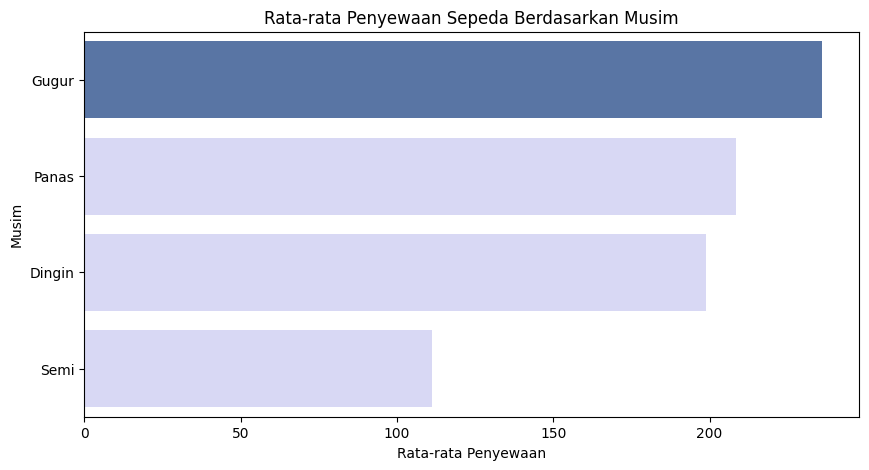

In [17]:
season_df = main_data.groupby("season")["cnt"].mean().reset_index()

season_map = {
    1: "Semi",
    2: "Panas",
    3: "Gugur",
    4: "Dingin"
}

season_df["season"] = season_df["season"].map(season_map)

season_df = season_df.sort_values("cnt", ascending=False)

colors = ["#4C72B0"] + ["#D3D3F9"] * (len(season_df)-1)

plt.figure(figsize=(10,5))

sns.barplot(
    y="season",
    x="cnt",
    data=season_df,
    order=season_df["season"],
    palette=colors
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Rata-rata Penyewaan")
plt.ylabel("Musim")

plt.show()

### Pertanyaan 2:

/tmp/ipykernel_46476/2422367405.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = main_data.pivot_table(


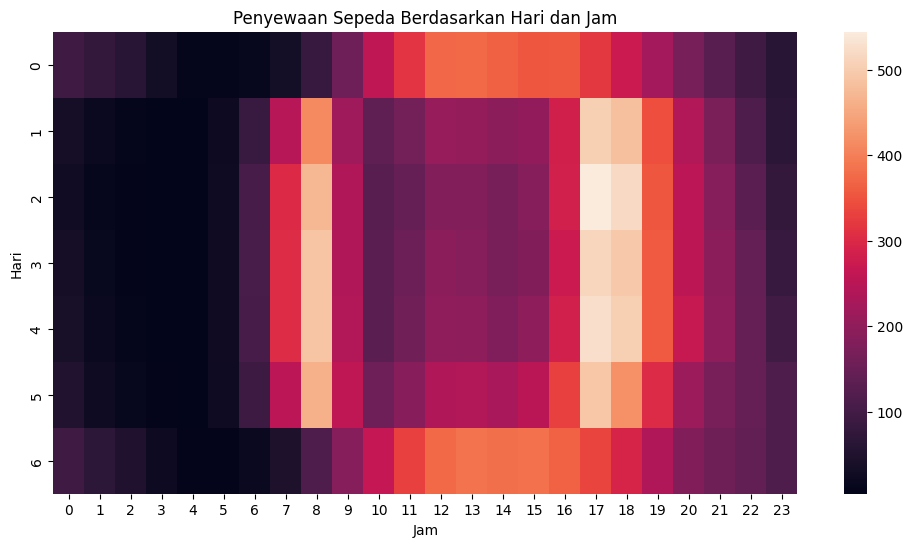

In [18]:
plt.figure(figsize=(12,6))

pivot_table = main_data.pivot_table(
    values='cnt',
    index='weekday',
    columns='hr',
    aggfunc='mean'
)

sns.heatmap(pivot_table, cmap="rocket")

plt.title("Penyewaan Sepeda Berdasarkan Hari dan Jam")
plt.xlabel("Jam")
plt.ylabel("Hari")

plt.show()

**Insight:**
- Pertanyaan 1 : Apakah musim mempengaruhi jumlah sepeda yang disewa?  
Berdasarkan visualisasiyang sudah dibuat, jawaban pertanyaan pertama adalah betul cuaca mempengaruhi jumlah sewa. Musim gugur menjadi tertinggi karena temperature yang cocok untuk bersepeda. Musim semi dan musim dingin memiliki jumlah penyewa yang lebih sedikit karena orang-orang lebih memilih moda transportasi yang lebih tertutup untuk mengatasi suhu dingin.
- Pertanyaan 2 : Apakah ada lonjakan penyewaan sepeda pada jam tertentu? apa penyebabnya?  
Ya. berdasarkan heatmap yang telah disajikan pada hari kerja (senin-jumat) terdapat pola yang mirip dimana terjadi lonjakan sewa dii jam berangkkat dan pulang kerja. Hal ini menunjukan sewa sepeda menjadi moda transportasii pilihan para pekerja kantoran.

## Analisis Lanjutan (Opsional)

In [19]:
daily_main = main_data.groupby("dteday").agg({
    "cnt": "sum",
    "temp": "mean",
}).reset_index()

# Manual Grouping
cluster_df = daily_main[['cnt','temp']]

cluster_df['cluster'] = pd.cut(
    cluster_df['cnt'],
    bins=3,
    labels=['Rendah','Sedang','Tinggi']
)

cluster_df.head()

,cnt,temp,cluster
0,985,0.344167,Rendah
1,801,0.363478,Rendah
2,1349,0.196364,Rendah
3,1562,0.200000,Rendah
4,1600,0.226957,Rendah


Text(0.5, 1.0, 'Suhu dan Jumlah Sewa')

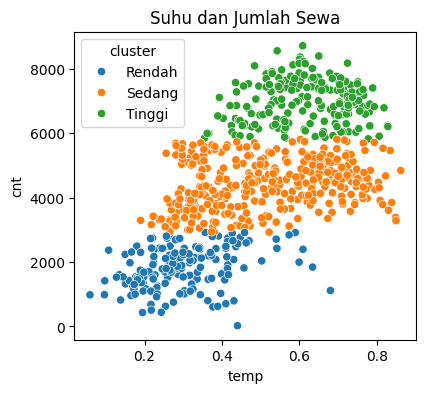

In [20]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.scatterplot(data=cluster_df, x='temp', y='cnt', hue='cluster')
plt.title("Suhu dan Jumlah Sewa")

# **Clustering berdasarkan suhu**
---
- Cluster Rendah: Menunjukkan rendahnya jumlah sewa pada suhu dingin.
- Cluster Sedang: Menunjukkan jumlah sewa yang cukup banyak dengan range suhu yang lebih luas.
- Cluster Tinggi: Menunjukkan tingginya jumlah sewa pada suhu yang dinilai nyaman bagi para penyewa.


## Conclusion

- **Apakah musim mempengaruhi jumlah sepeda yang disewa?**  
Ya, musim berpengaruh pada jumlah sewa sepeda. Musim dengan suhu yang nyaman seperti musim gugur dan musim panas memiliki jumlah penyewa yang lebih banyak dibanding dengan musim dengan suhu yang dingin seperti musim dingin dan musim semi.
- **Apakah ada lonjakan penyewaan sepeda pada jam tertentu? apa penyebabnya?**  
Ya, ada. Pada hari kerja yaitu hari Senin hingga Jumat terdapat pola yang jelas di mana terjadi lonjakan sewa di jam berangkat kerja sekitar jam 8 pagi dan jam pulang kerja sekitar jam 5-6 sore. Pola ini tidak terlalu tampak pada hari weekends seperti Sabtu dan Minggu. Dapat disimpulkan bahwa lonjakan ini terjadio karena sepeda adalah moda transportasi pilihan para pekerja kantoran.